/home/kianmilani/miniconda3/envs/gpu311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


/home/kianmilani/Projects/adefc-vortex/aefc_vortex


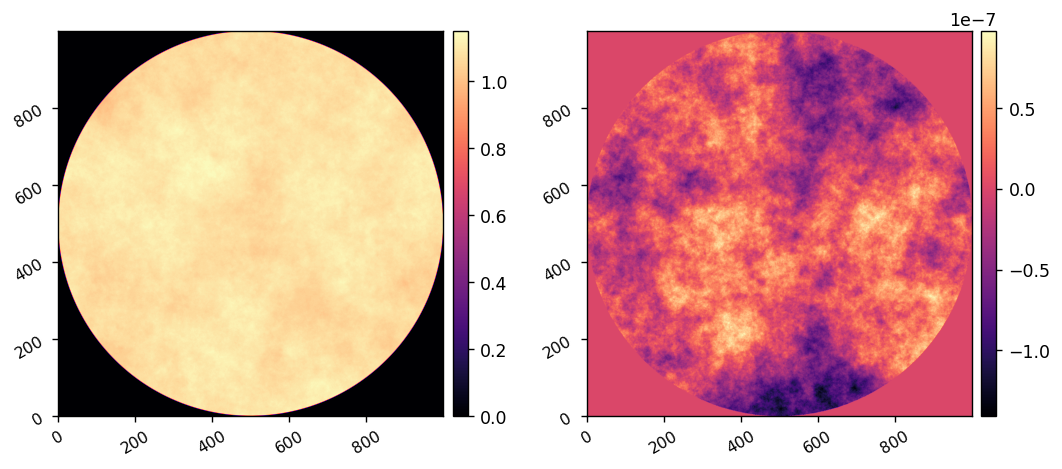

In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import copy
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from importlib import reload

from scipy.optimize import minimize

import aefc_vortex
from aefc_vortex.math_module import xp, xcipy, ensure_np_array
from aefc_vortex import utils
from aefc_vortex.imshows import imshow1, imshow2, imshow3
from aefc_vortex import dm
from aefc_vortex import props
from aefc_vortex import aefc_1dm as adefc
import aefc_vortex.pwp as pwp
import aefc_vortex.scoob_model as scoobm

wavelength_c = 633e-9

wfe_amp = utils.load_fits('data/scoob_example_wfe_amp.fits')
wfe_opd = utils.load_fits('data/scoob_example_wfe_opd.fits')
imshow2(wfe_amp, wfe_opd)

fig_path = aefc_vortex.path/'figs'


# Test the forward model parameters.

Oversampling > 2x suggested for reliable results in Fresnel propagation.


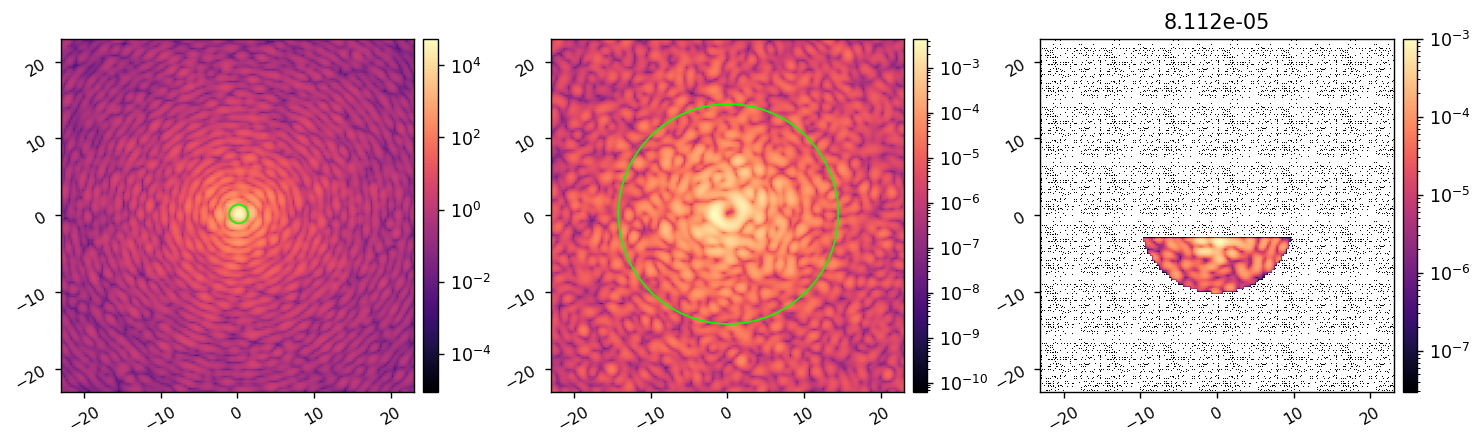

In [4]:
reload(scoobm)
I = scoobm.MODEL(
    dm_beam_diam=9.1*u.mm, 
    lyot_pupil_diam=9.1*u.mm,
    dm_shift=np.array([-0.1, 0.1])*u.mm,
    lyot_shift=np.array([0.1, -0.1])*u.mm,
)
I.AMP = wfe_amp
I.OPD = wfe_opd

I.reverse_lyot = 1
I.flip_lyot = 1
# I.det_rotation = 178

I.setattr('use_vortex', False)
ref_psf = I.snap()
I.setattr('Imax_ref', xp.max(ref_psf))
I.setattr('use_vortex', True)
ref_coro_im = I.snap()

iwa = 3
owa = 10
rot = 90
control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=iwa, rotation=rot)
mean_ni = xp.mean(ref_coro_im[control_mask])

psf_center = (I.psf_pixelscale_lamDc/2, I.psf_pixelscale_lamDc/2)
imshow3(
    ref_psf, ref_coro_im, ref_coro_im*control_mask, '', '', f'{mean_ni:.3e}',
    lognorm=True, pxscl=I.psf_pixelscale_lamDc, 
    patches1=[Circle(psf_center, 1.22, fill=False, color='lime')], 
    patches2=[Circle(psf_center, I.control_rad, fill=False, color='lime')],
)

Oversampling > 2x suggested for reliable results in Fresnel propagation.


[-5.75, 5.75, -5.75, 5.75]


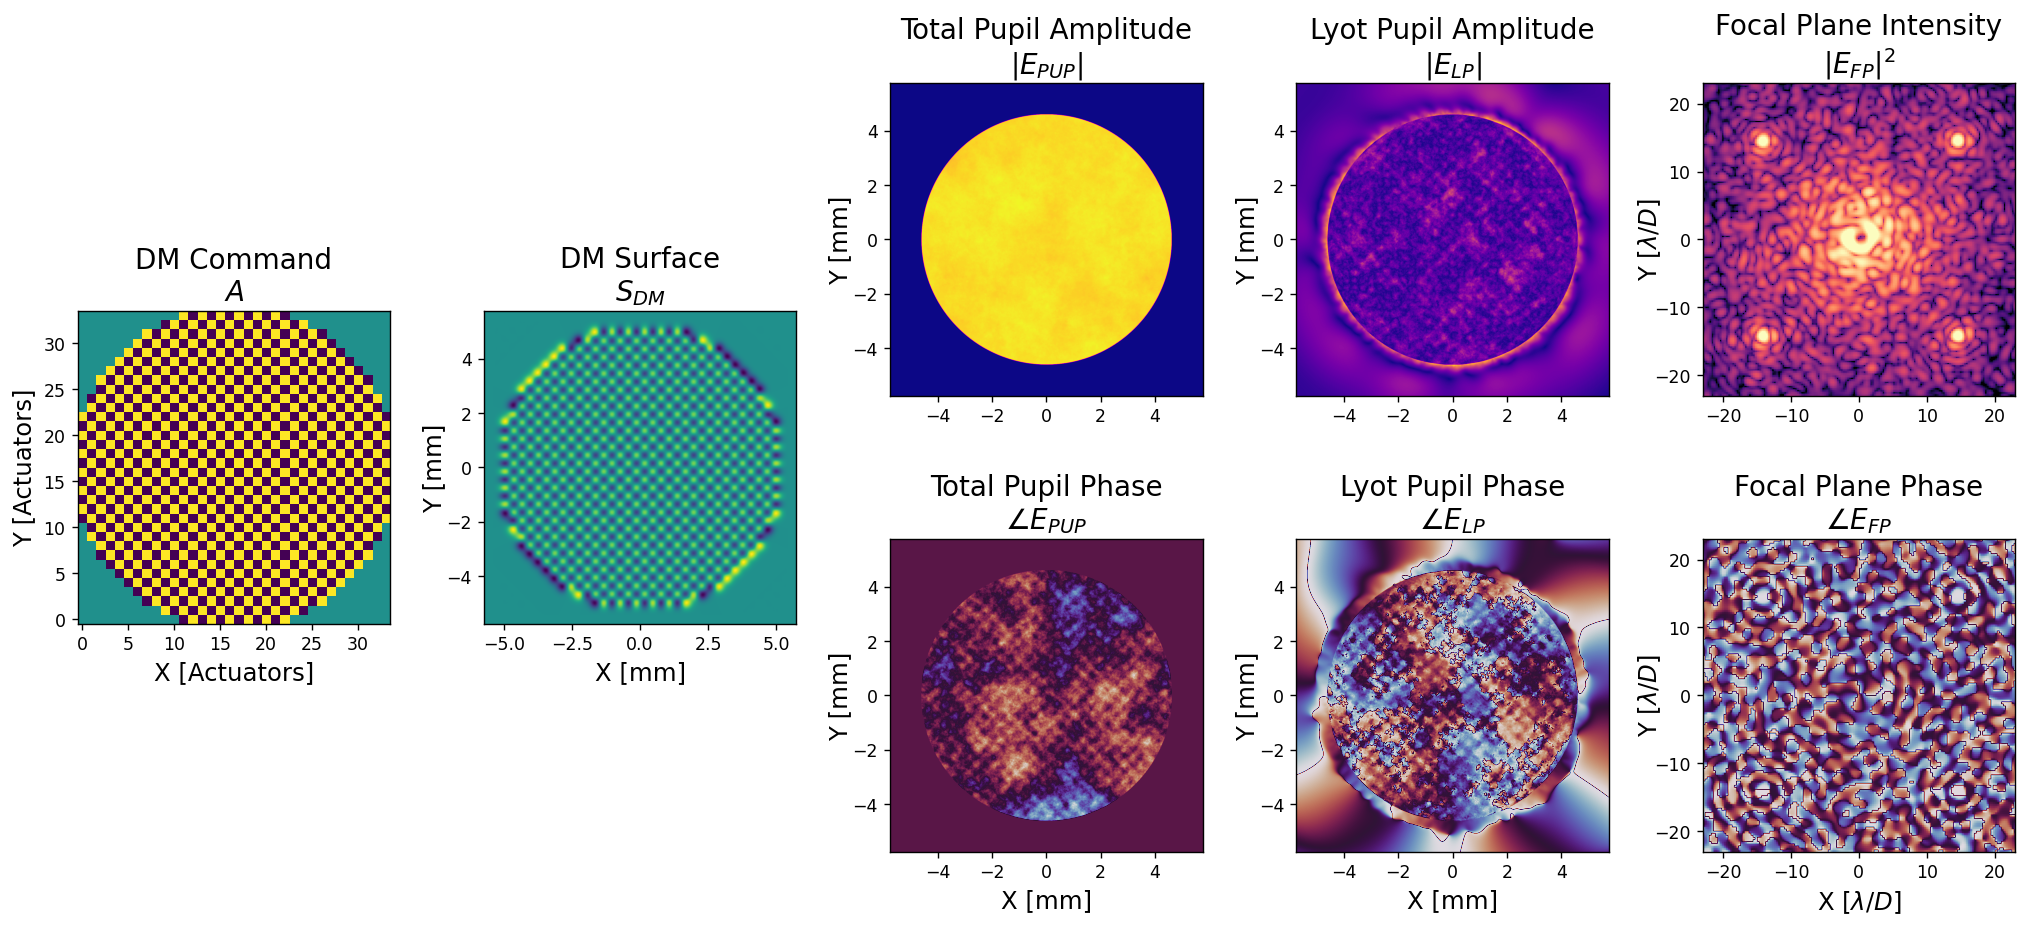

In [5]:
reload(scoobm)
reload(utils)
reload(props)
M = scoobm.MODEL(
    # dm_beam_diam=9.4*u.mm, 
    # lyot_pupil_diam=9.4*u.mm,
    # dm_shift=np.array([0,0])*u.mm,
    # lyot_shift=np.array([0,0.3])*u.mm,
    # vortex_sign=-1, 
)
M.AMP = wfe_amp
M.OPD = wfe_opd

M.reverse_lyot = 1
M.flip_lyot = 1
# M.det_rotation = 178

M.setattr('use_vortex', False)
ref_psf = M.snap()
M.setattr('Imax_ref', xp.max(ref_psf))

command = np.zeros((M.Nact, M.Nact))
command = 50e-9*utils.make_f(h=10, w=6, shift=(0,0))
command = 20e-9*utils.make_fourier_command(x_cpa=17, y_cpa=17)
# fpwf = M.forward(acts, use_vortex=0, plot=True)
E_FP = M.forward(
    command[M.dm_mask], 
    use_vortex=1, 
    plot=0, 
    fancy_plot=1, 
    # fancy_plot_fname=fig_path/'forward_model.pdf',
)



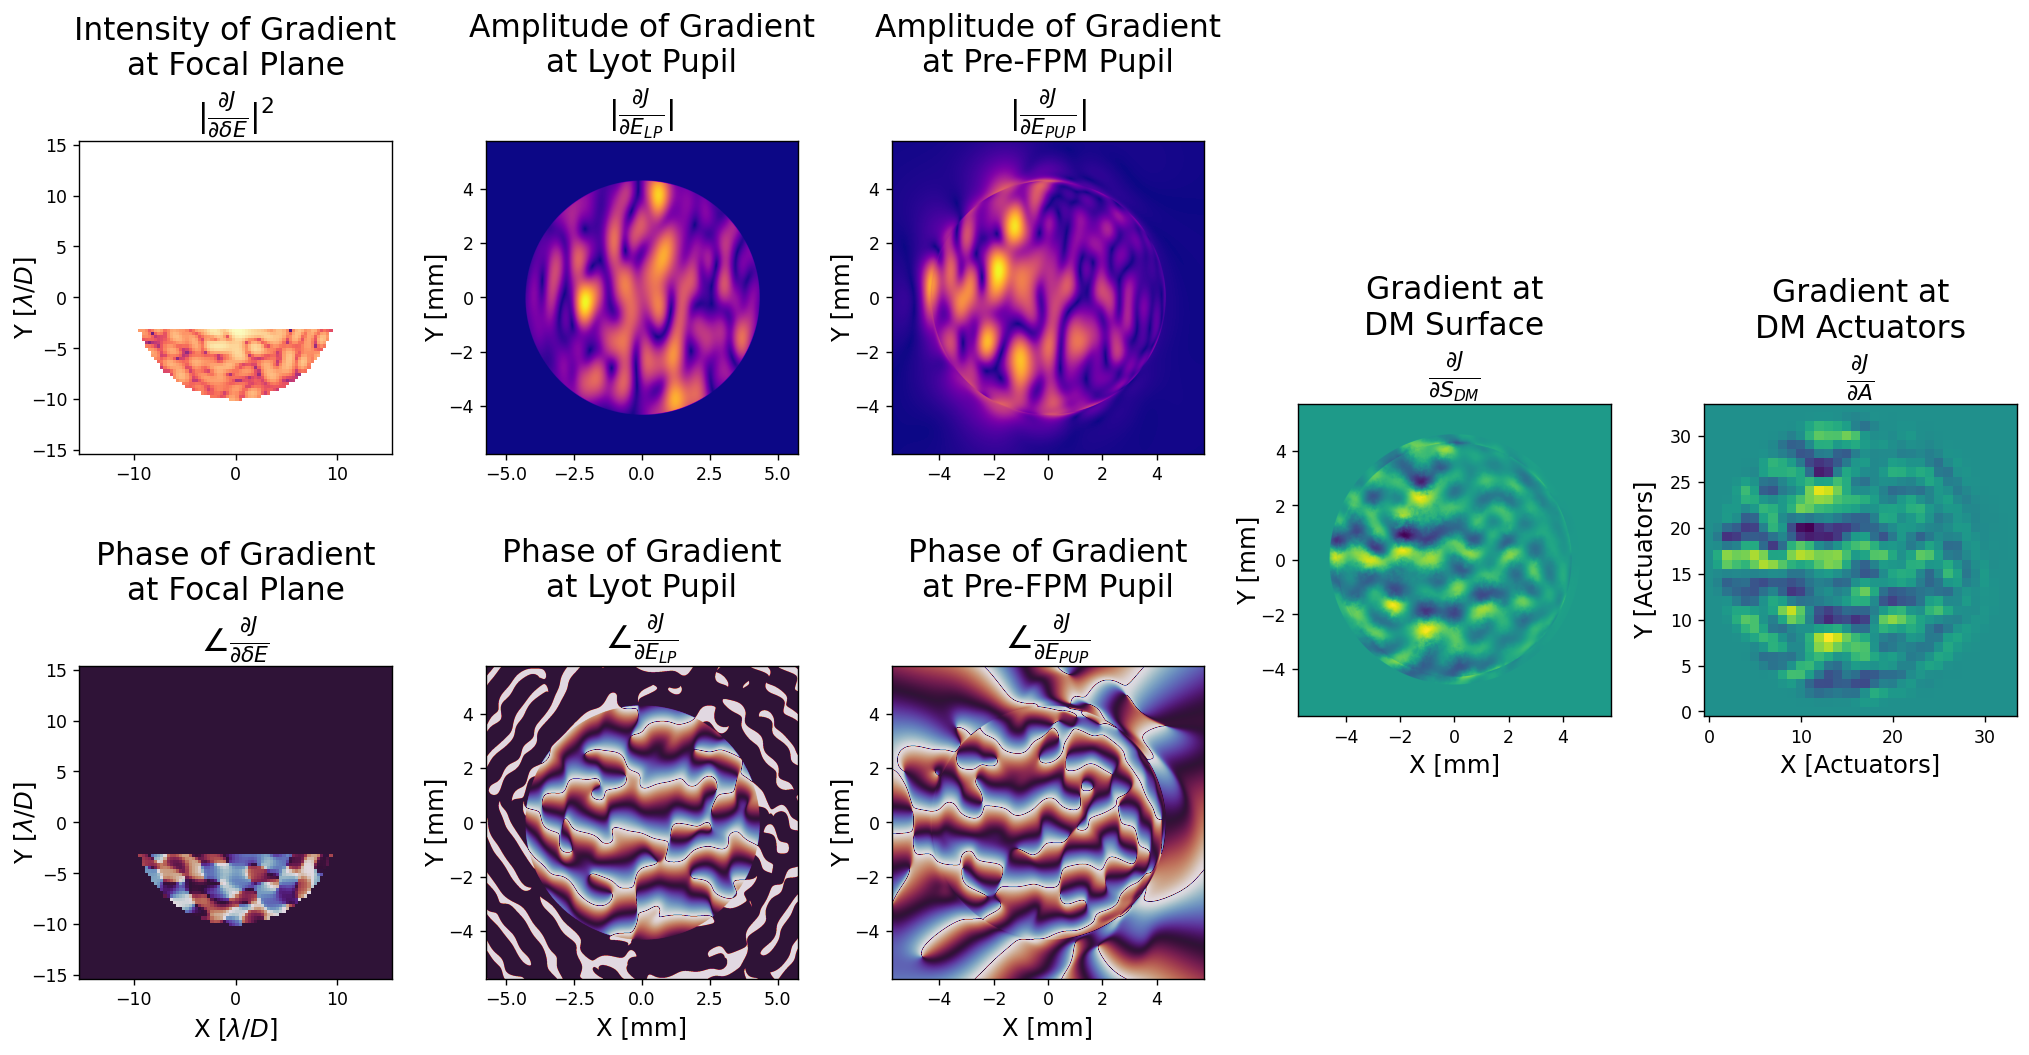

In [6]:
reload(scoobm)
del_acts = np.zeros(M.Nacts)
current_acts = xp.zeros(M.Nacts)

rmad_vars = {
    'E_ab': E_FP*control_mask,
    'E_FP_NOM':E_FP,
    'current_acts':current_acts,
    'control_mask':control_mask,
    'wavelength':M.wavelength_c,
    'r_cond':1e-3,
}

J, dJ_dA = scoobm.val_and_grad(
    del_acts, 
    M, 
    rmad_vars,
    verbose=0, 
    plot=0, 
    fancy_plot=1,
    # fancy_plot_fname=fig_path/'adjoint_model.pdf',
)

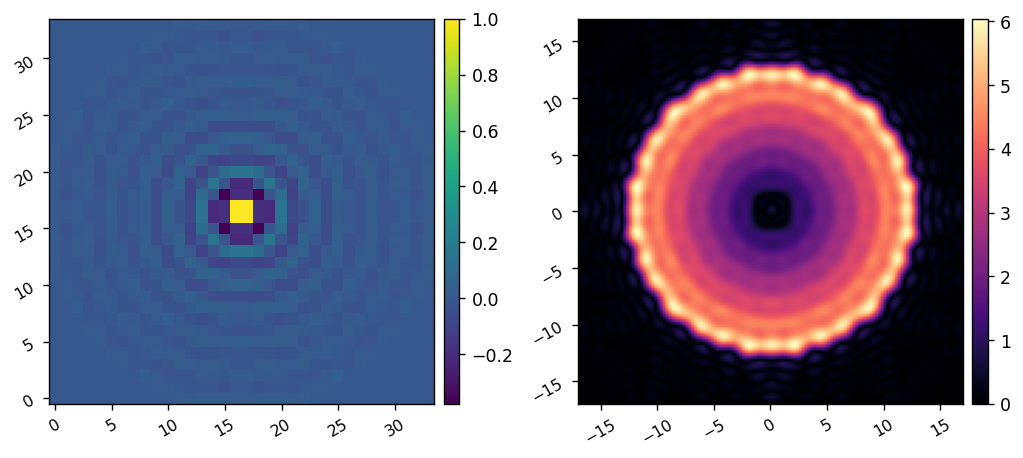

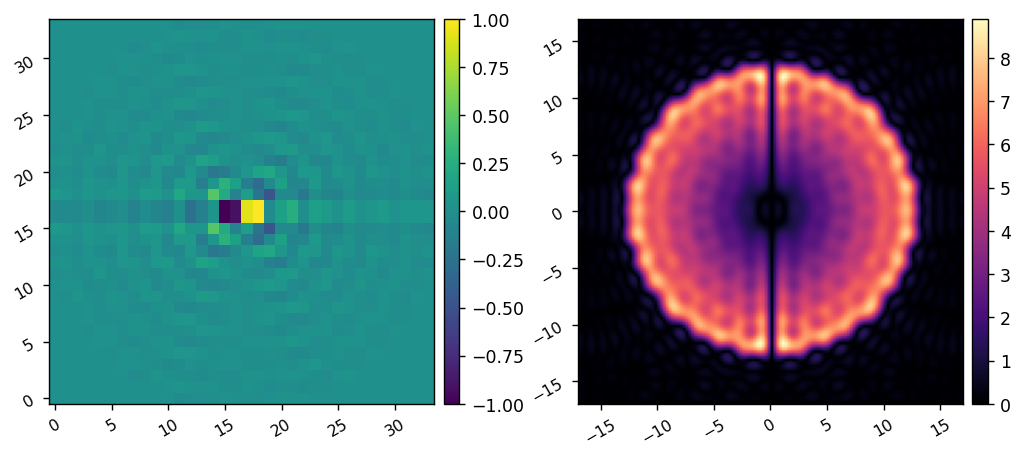

In [7]:
reload(utils)
fourier_probes = utils.create_fourier_probes(
    I.dm_mask, I.npsf, I.psf_pixelscale_lamDc, 
    iwa-0.5, owa+2, 
    # edge=iwa-0.5,
    fourier_sampling=0.75, 
    nprobes=2,
    plot=True,
    use_weighting=True
)
fourier_probes[0] = xp.rot90(fourier_probes[0])
fourier_probes[1] = xp.rot90(fourier_probes[1])

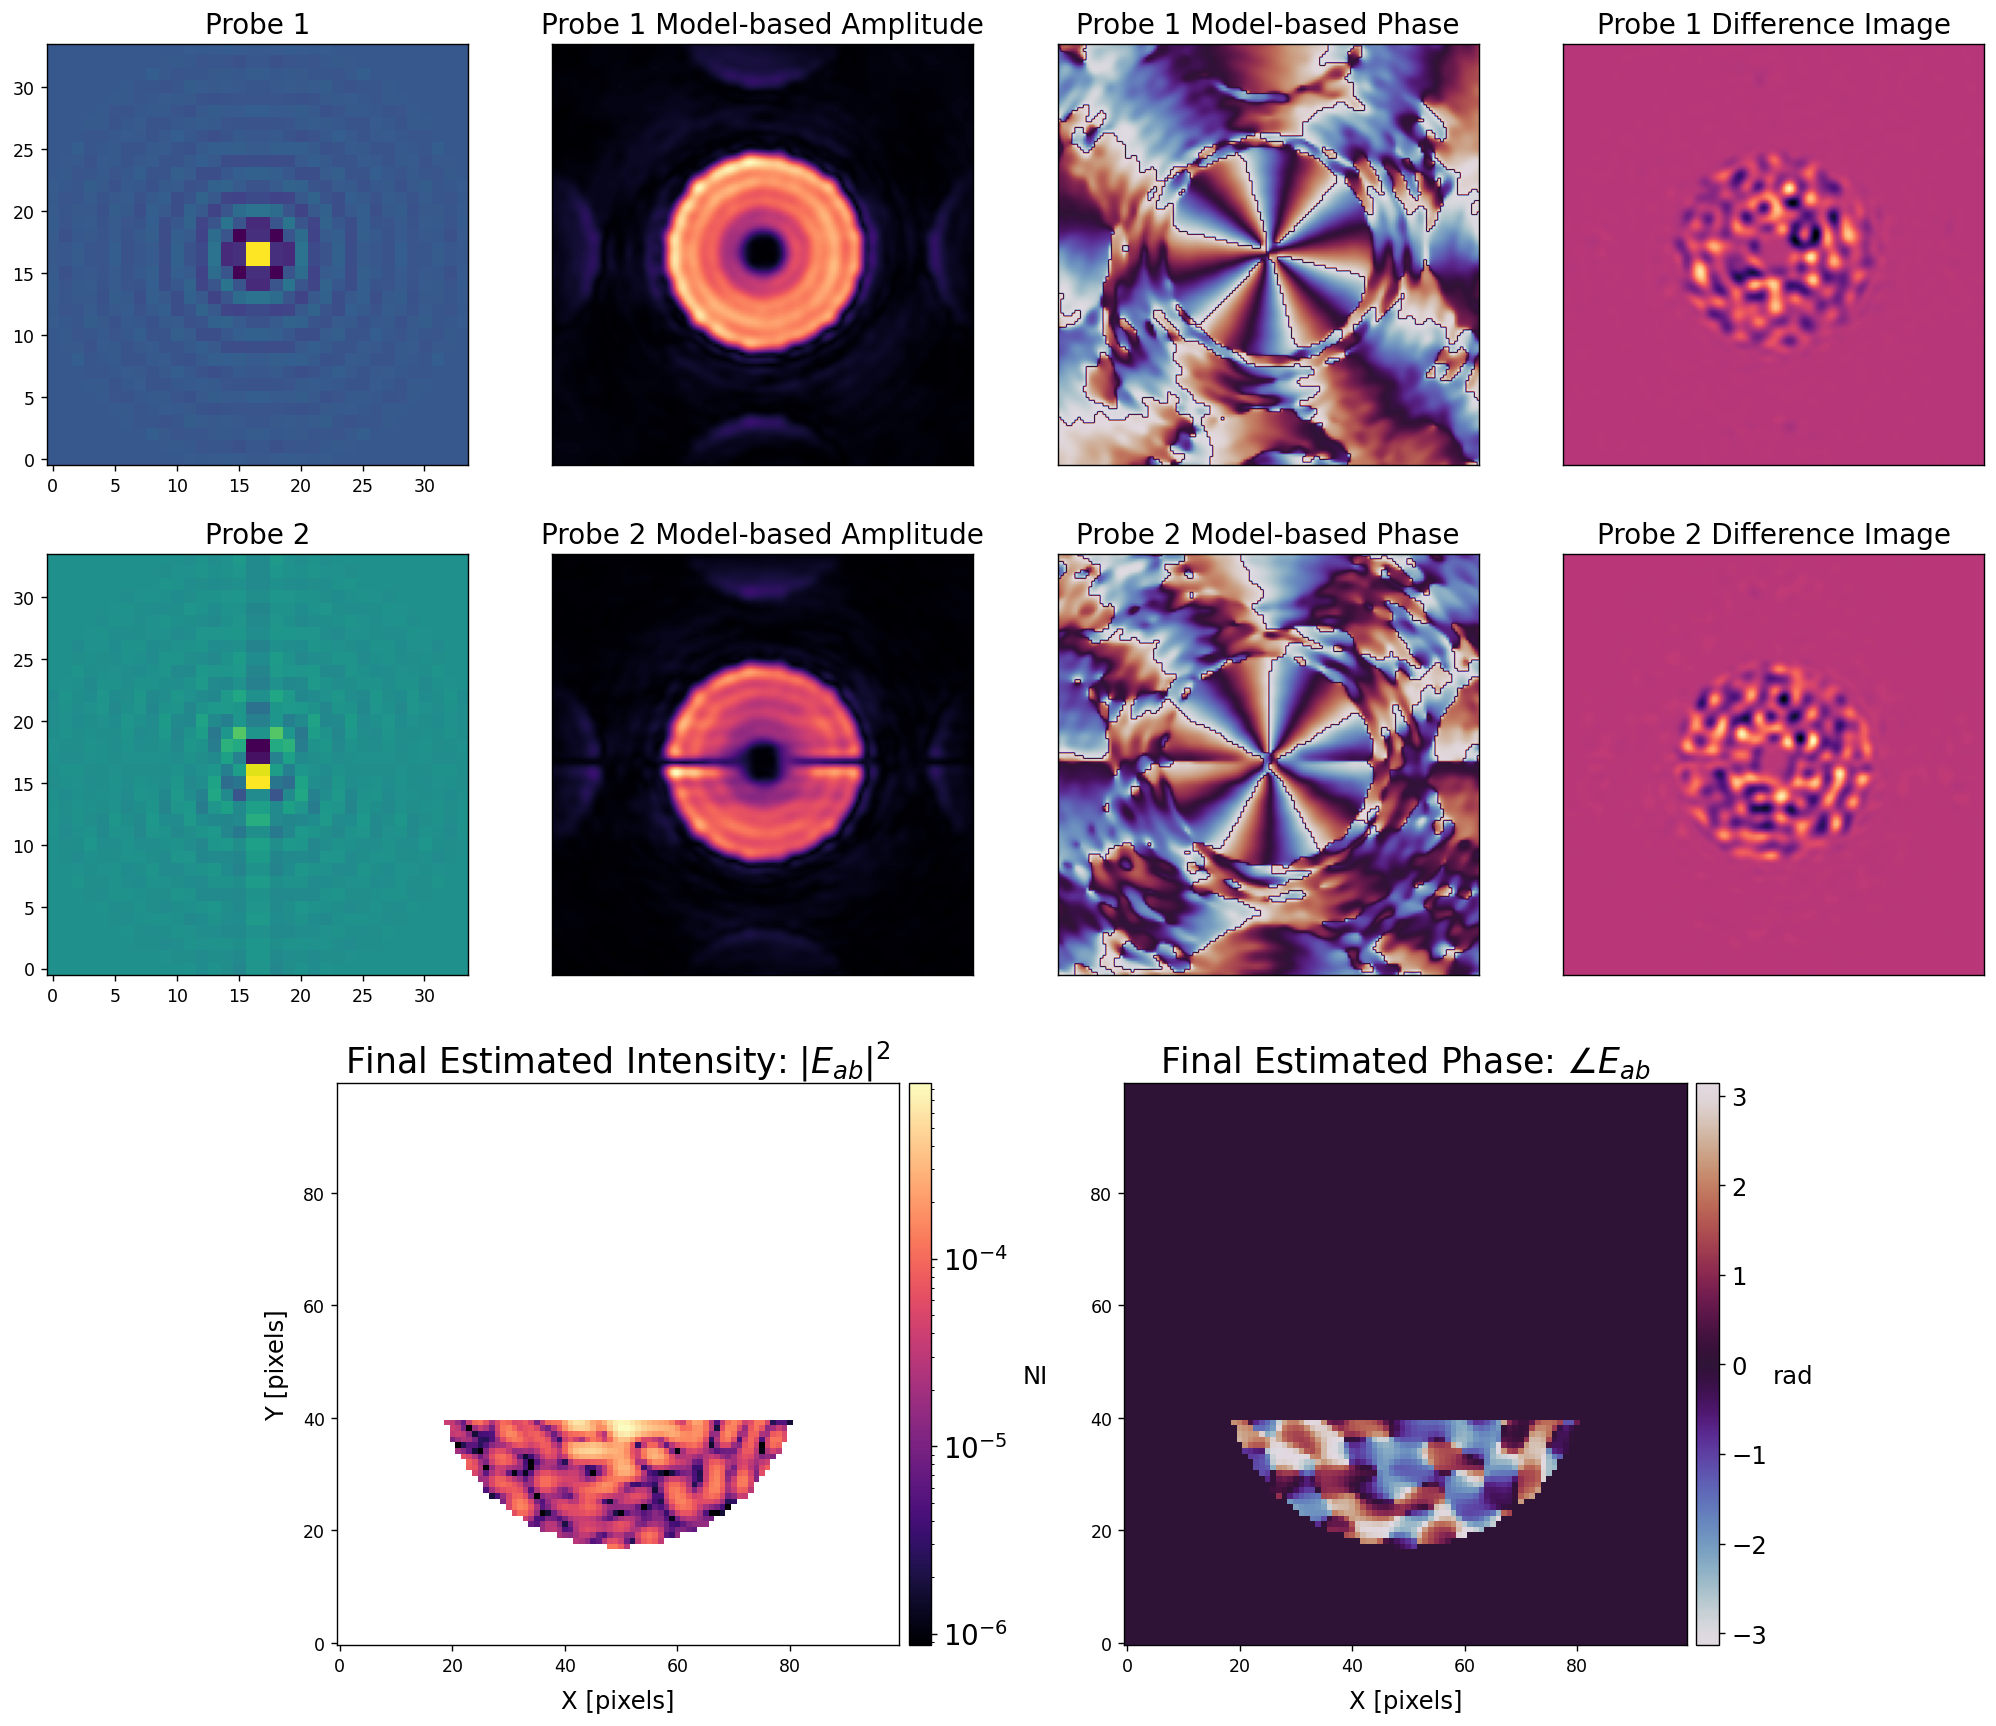

In [8]:
reload(pwp)

current_acts = xp.zeros(I.Nacts)

I.set_dm(scoobm.acts_to_command(current_acts, I.dm_mask))
E_pwp, E_probes, diff_ims = pwp.run(
    I, M, 
    control_mask, 
    fourier_probes, 
    2.5e-9, 
    I.wavelength_c,
    plot=True,
    # plot_est=True,
    Ndms=1,
    return_all=True,
    # plot_fname=fig_path/'pwp_example.pdf',
)
I_pwp = xp.abs(E_pwp)**2
P_pwp = xp.angle(E_pwp)

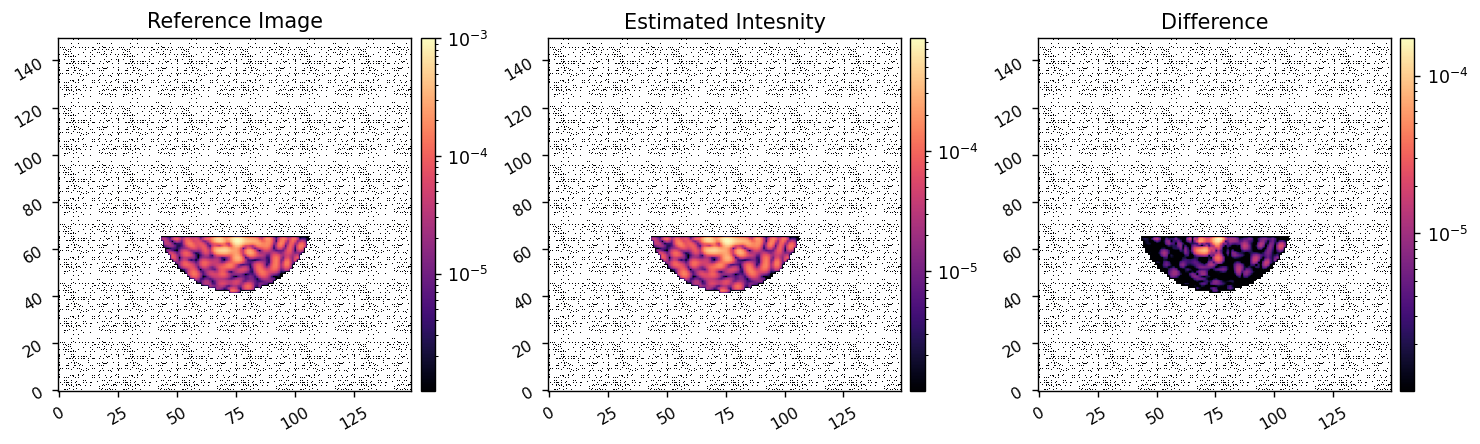

In [9]:
sf = 1
I_diff = ref_coro_im*control_mask - sf*I_pwp
vmin = xp.max(ref_coro_im*control_mask)/1e3
imshow3(
    ref_coro_im*control_mask, sf*I_pwp, xp.abs(I_diff), 
    'Reference Image', 'Estimated Intesnity', 'Difference',
    lognorm1=True, lognorm2=True, 
    vmin1=vmin, vmin2=vmin, 
    lognorm3=True, vmin3=vmin,
)

In [23]:
I.zero_dm()
data = {
    # 'ref_im':ref_coro_im, 
    'images':[ref_coro_im],
    'efields':[],
    'commands':[],
    'del_commands':[],
    'reg_conds':[],
    'bfgs_tols':[],
    'pixelscale':I.psf_pixelscale_lamDc,
    'control_mask':control_mask, 
}

Running iteration 28
Running PWP ...


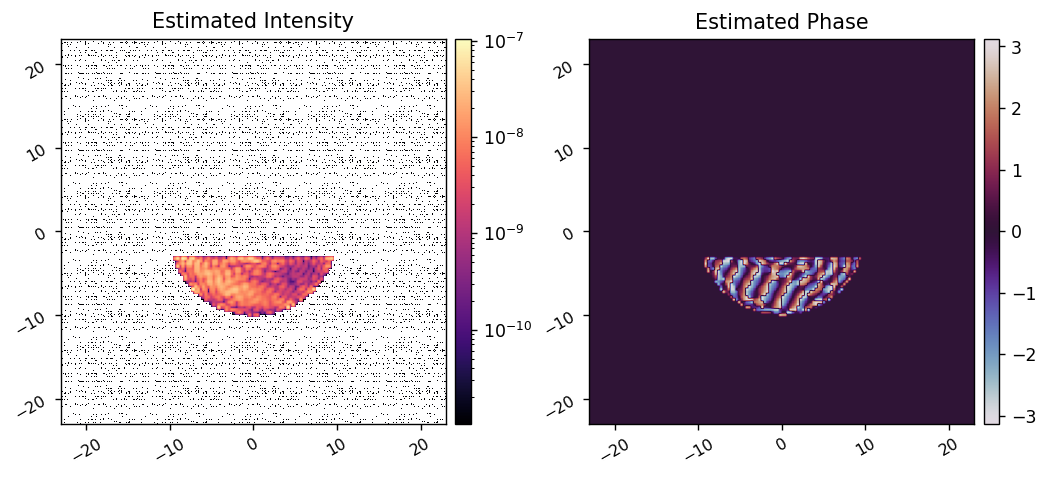

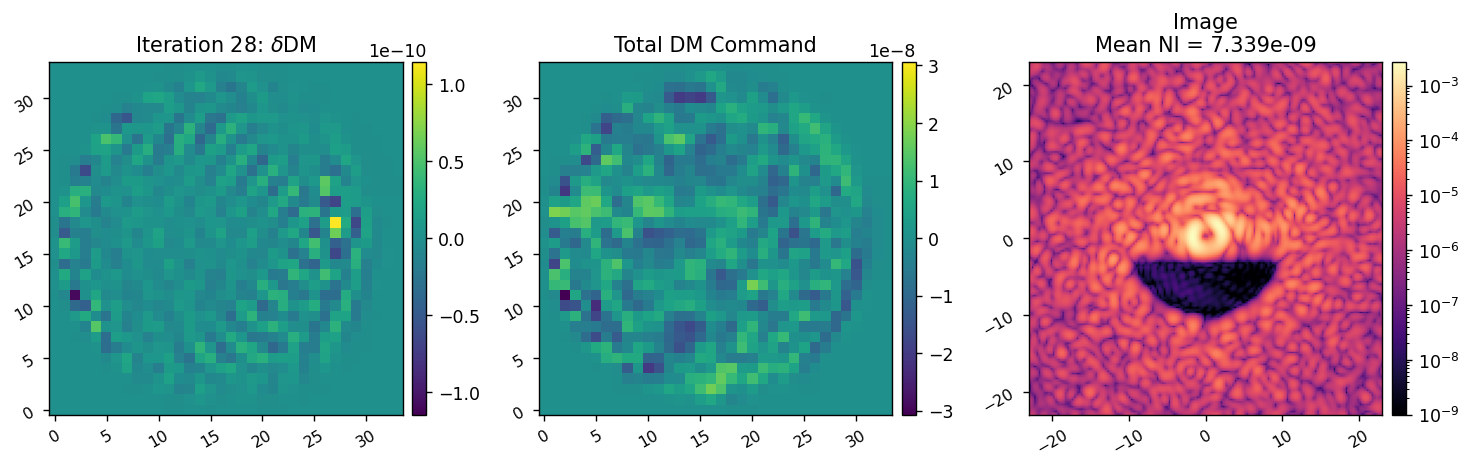

Running iteration 29
Running PWP ...


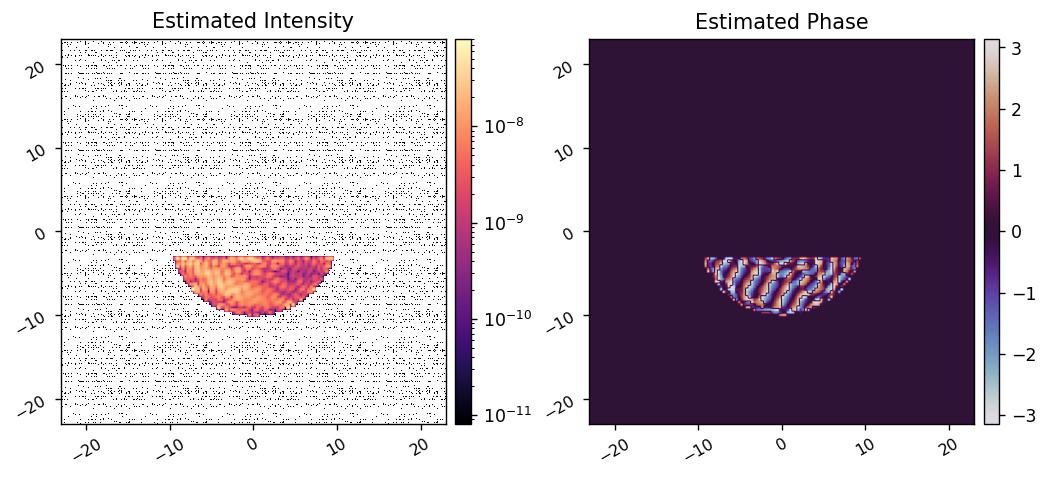

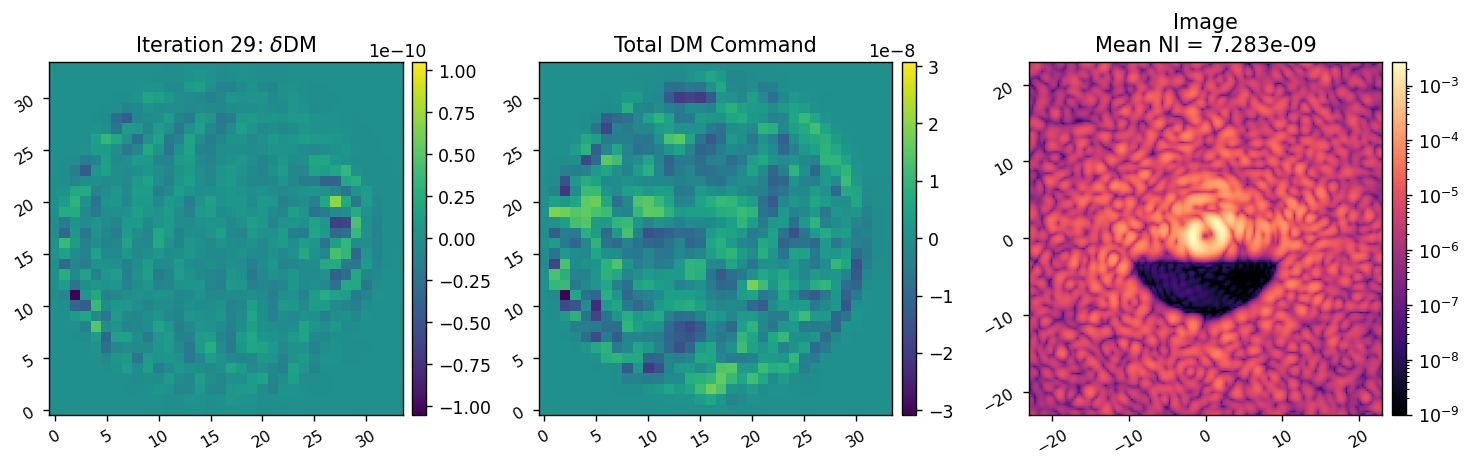

Running iteration 30
Running PWP ...


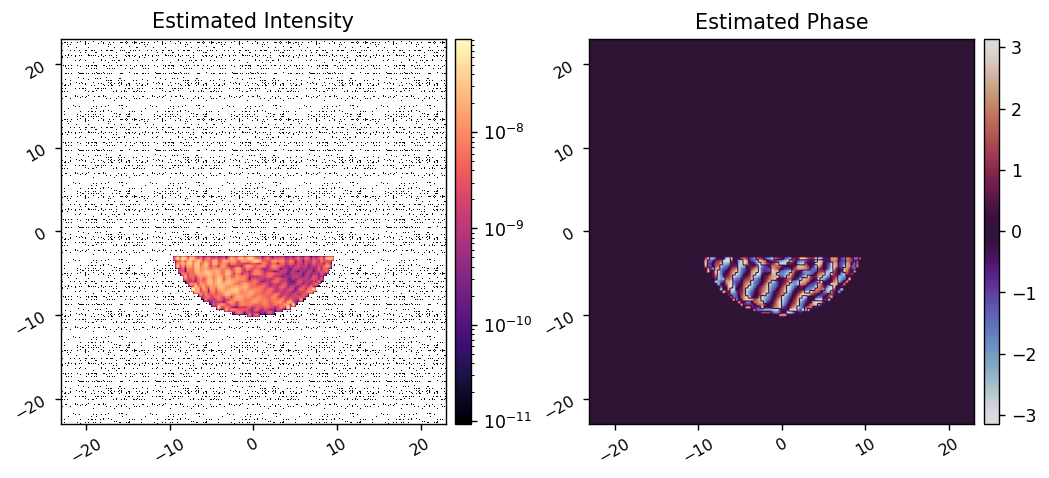

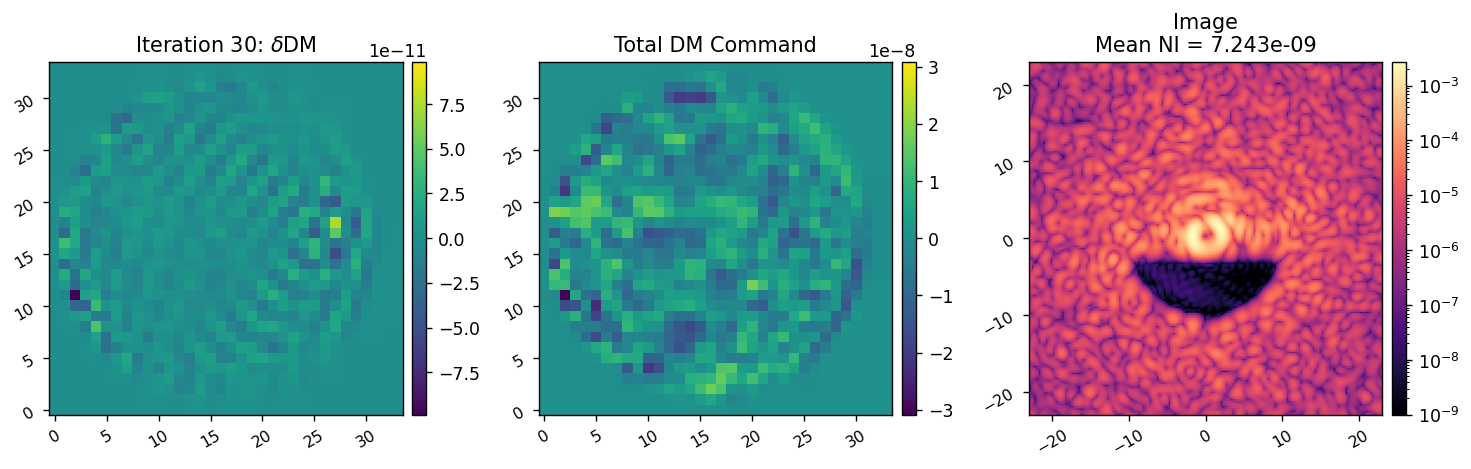

In [33]:
reload(scoobm)
reload(adefc)
reload(utils)

r_cond = 1e-1
# r_cond = 1e-2
# r_cond = 1e-3
# r_cond = 1e-4
# r_cond = 1e-5
# r_cond = 1e-6
# r_cond = 1e-7
# r_cond = 1e-8

bfgs_tol = 1e-2
bfgs_tol = 1e-3
# bfgs_tol = 1e-4
# bfgs_tol = 1e-5

bfgs_opts = {
    # 'disp':1,
    # 'maxiter':50,
    # 'maxls':10,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

pwp_params = {
    'control_mask':control_mask, 
    'probes':fourier_probes,
    'probe_amp':2.5e-9,
    # 'probe_amp':1.5e-9,
    'probe_amp':0.5e-9,
    'wavelength':wavelength_c,
    # 'plot':True,
    'plot_est':True, 
}

data = adefc.run(
    I, 
    M, 
    scoobm.val_and_grad, 
    control_mask, 
    data,
    pwp_params=pwp_params,
    Nitr=3, 
    reg_cond=r_cond,
    bfgs_tol=bfgs_tol,
    bfgs_opts=bfgs_opts,
    gain=1,
)


In [35]:
utils.save_pickle('data/scoob_aefc_pwp_sim_with_ME.pkl', data)

Saved data to:  data/scoob_aefc_pwp_sim_with_ME.pkl


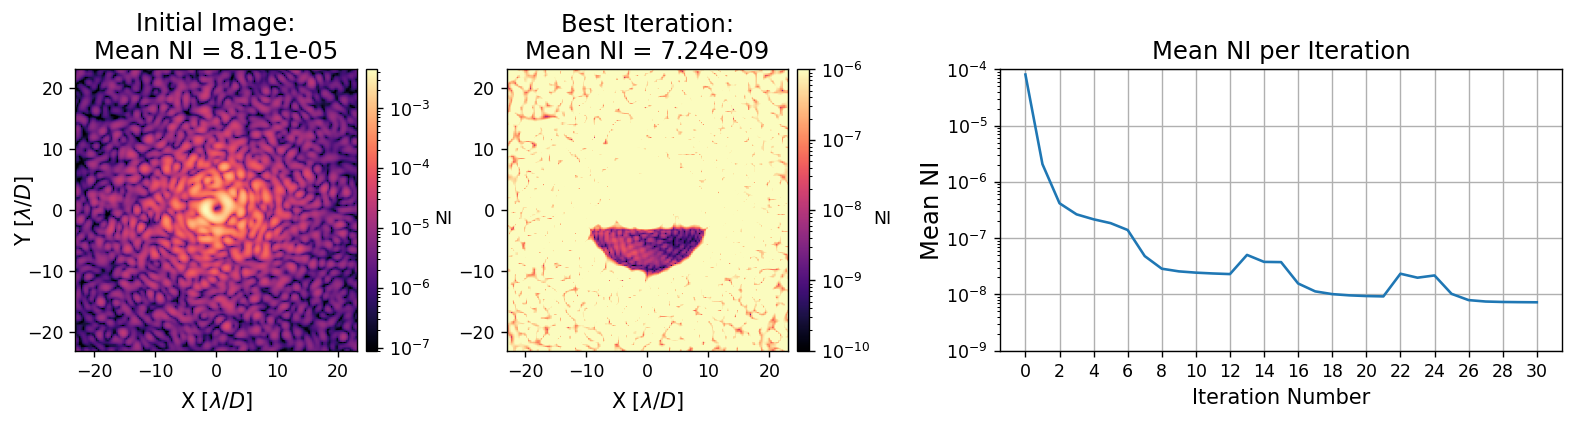

In [36]:
import aefc_vortex.imshows as imshows
reload(imshows)
imshows.plot_howfsc_data(
    data, 
    vmin=1e-9, 
    vmax=1e-4,
    im1vmax=1e-7,
    im1vmin=xp.max(data['images'][0]),
    im2vmax=1e-6,
    im2vmin=1e-10,
    fname=fig_path/'scoob_fraunhofer_sim_with_me.pdf',
)

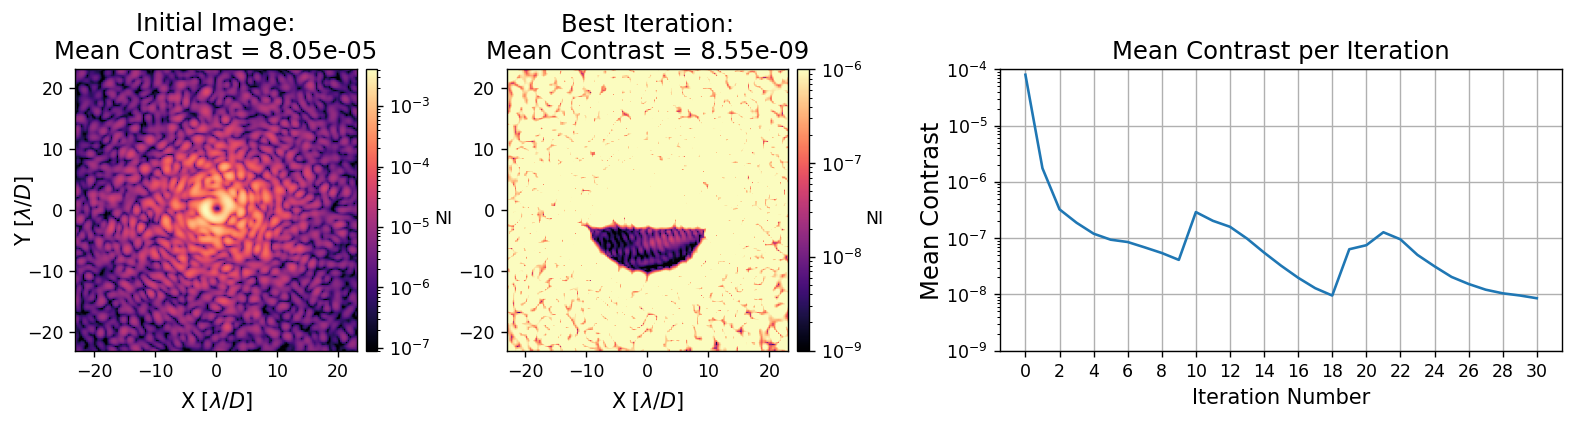

In [ ]:
import aefc_vortex.imshows as imshows
reload(imshows)
imshows.plot_howfsc_data(
    data, 
    vmin=1e-9, 
    vmax=1e-4,
    im1vmax=1e-7,
    im1vmin=xp.max(data['images'][0]),
    im2vmax=1e-6,
    im2vmin=1e-9,
    # fname=fig_path/'scoob_fraunhofer_sim_with_me.pdf',
)

In [46]:
1143.520/3600 * 60

19.058666666666667

In [ ]:
utils.imshow(
    []
)

In [9]:
aefc_data = utils.load_pickle('data/scoob_aefc_pwp_sim.pkl')

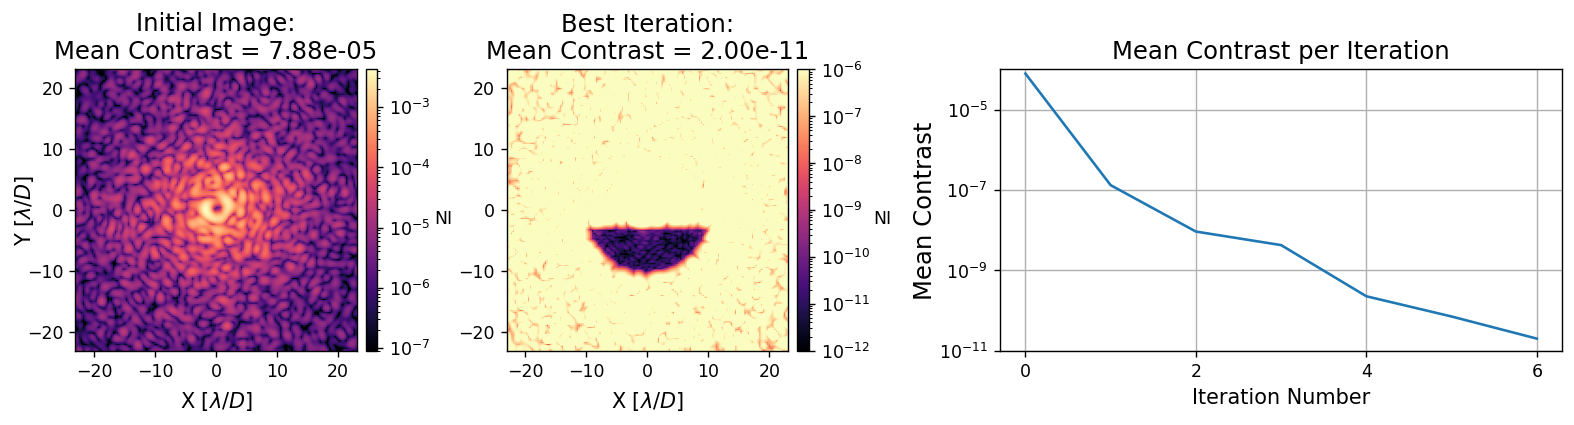

In [18]:
import aefc_vortex.imshows as imshows
reload(imshows)
imshows.plot_howfsc_data(
    aefc_data, 
    vmin=1e-11, 
    vmax=1e-4,
    im1vmax=1e-7,
    im1vmin=xp.max(aefc_data['images'][0]),
    im2vmax=1e-6,
    im2vmin=1e-12,
    fname=fig_path/'scoob_fraunhofer_sim.pdf',
)